In [1]:
### BLOCK 1 (PHASE 11): SETUP, MOUNT DRIVE, & DEFINE PATHS ###

print("--- Block 1 (Phase 11): Setup for 'Hyper-Feature' Experiment ---")

# --- 1. Import All Libraries ---
import os
import cv2
import numpy as np
import pandas as pd
from google.colab import drive
import glob
import shutil
import joblib # For saving models
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
# --- NEW LIBRARIES ---
from skimage.feature import graycomatrix, graycoprops # For Haralick
from skimage.feature import local_binary_pattern # <-- NEW! For LBP
# ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- 2. Mount Drive ---
print("Mounting Google Drive...")
drive.mount('/content/drive', force_remount=True)

# --- 3. Define Paths ---
BASE_PROJECT_FOLDER = 'Thermal_Project'
DRIVE_PATH = os.path.join('/content/drive/MyDrive', BASE_PROJECT_FOLDER)

# Paths to your *original* videos
DRY_VIDEOS_PATH = os.path.join(DRIVE_PATH, 'dry')
WET_VIDEOS_PATH = os.path.join(DRIVE_PATH, 'wet')

# Path for our NEW "Hyper-Feature" data
OUTPUT_CSV_PATH = os.path.join(DRIVE_PATH, 'hyper_feature_frame_data.csv')

# Image shape
IMG_HEIGHT = 224
IMG_WIDTH = 224

print(f"\nBase project path: {DRIVE_PATH}")
print(f"NEW 'Hyper-Feature' data will be saved to: {OUTPUT_CSV_PATH}")

if not os.path.exists(DRY_VIDEOS_PATH) or not os.path.exists(WET_VIDEOS_PATH):
    print("\nWARNING: Original 'dry' or 'wet' video folders not found!")
else:
    print("Successfully found original video folders.")

print("\nBlock 1 Complete. Ready for Block 2.")


--- Block 1 (Phase 11): Setup for 'Hyper-Feature' Experiment ---
Mounting Google Drive...
Mounted at /content/drive

Base project path: /content/drive/MyDrive/Thermal_Project
NEW 'Hyper-Feature' data will be saved to: /content/drive/MyDrive/Thermal_Project/hyper_feature_frame_data.csv
Successfully found original video folders.

Block 1 Complete. Ready for Block 2.


In [2]:
### BLOCK 2 (PHASE 11): DEFINE "HYPER-FEATURE" EXTRACTOR (FIXED) ###

print("--- Block 2 (Phase 11): Defining 'Hyper-Feature' Functions ---")

# --- 1. Define Haralick Texture Function (from last time) ---
def get_haralick_features(frame_gray_8bit):
    """Calculates 4 key Haralick Texture features."""
    try:
        glcm = graycomatrix(frame_gray_8bit,
                            distances=[1],
                            angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                            levels=256,
                            symmetric=True,
                            normed=True)

        contrast = graycoprops(glcm, 'contrast').mean()
        correlation = graycoprops(glcm, 'correlation').mean()
        energy = graycoprops(glcm, 'energy').mean()
        homogeneity = graycoprops(glcm, 'homogeneity').mean()

        return [contrast, correlation, energy, homogeneity]
    except Exception as e:
        print(f"  Warning: Error in Haralick: {e}")
        return [np.nan] * 4

# --- 2. Define NEW Canny Edge Density Function ---
def get_canny_edge_density(frame_gray_8bit):
    """
    Calculates the density of edges in the frame.
    This quantifies the "edginess" Grad-CAM saw.
    """
    try:
        # 1. Find edges using Canny edge detector
        edges = cv2.Canny(frame_gray_8bit, 100, 200)

        # 2. Calculate density
        edge_density = np.sum(edges > 0) / edges.size
        return edge_density
    except Exception as e:
        print(f"  Warning: Error in Canny: {e}")
        return np.nan

# --- 3. Define NEW Local Binary Patterns (LBP) Function ---
def get_lbp_features(frame_gray_8bit):
    """
    Calculates Local Binary Patterns (LBP) features.
    This is a powerful texture classifier.
    """
    try:
        # 1. Set LBP parameters
        radius = 3
        n_points = 8 * radius

        # 2. Calculate LBP
        lbp = local_binary_pattern(frame_gray_8bit, n_points, radius, method='uniform')

        # 3. Create a histogram of the LBP results
        (hist, _) = np.histogram(lbp.ravel(),
                                 bins=np.arange(0, n_points + 3),
                                 range=(0, n_points + 2))

        # 4. Normalize the histogram
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-6) # Add 1e-6 to avoid division by zero

        # We'll just return the mean and std dev of the histogram as features
        lbp_mean = np.mean(hist)
        lbp_std = np.std(hist)

        return [lbp_mean, lbp_std]
    except Exception as e:
        print(f"  Warning: Error in LBP: {e}")
        return [np.nan] * 2

# --- 4. Define the Main "Hyper-Feature" Extractor Function ---
FRAME_SKIP = 30 # Process 1 frame per second (approx)

def extract_hyper_features(video_path, label, all_frames_data_list):
    """
    Loops through a video, extracts frames, and calculates
    ALL features (HSV, Haralick, Canny, LBP).
    """
    try:
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"  Warning: Could not open video file: {video_path}")
            return

        frame_count = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            if frame_count % FRAME_SKIP == 0:
                # 1. Resize and get basic frames
                frame_resized = cv2.resize(frame, (IMG_WIDTH, IMG_HEIGHT))
                frame_gray = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2GRAY)
                frame_hsv = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2HSV)
                frame_gray_8bit = cv2.normalize(frame_gray, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

                # --- 2. FEATURE SET 1: HSV Stats ---

                # --- THIS IS THE FIX ---
                # cv2.meanStdDev returns two 2D arrays: (mean, stddev)
                mean_vals, stddev_vals = cv2.meanStdDev(frame_hsv)
                (h_mean, s_mean, v_mean) = mean_vals.flatten()[:3]
                (h_std, s_std, v_std) = stddev_vals.flatten()[:3]
                # --- END OF FIX ---

                # --- 3. FEATURE SET 2: Haralick Texture ---
                (contrast, correlation, energy, homogeneity) = get_haralick_features(frame_gray_8bit)

                # --- 4. FEATURE SET 3: Canny Edge Density (NEW) ---
                edge_density = get_canny_edge_density(frame_gray_8bit)

                # --- 5. FEATURE SET 4: LBP Texture (NEW) ---
                (lbp_mean, lbp_std) = get_lbp_features(frame_gray_8bit)

                # 6. Store all 13 features
                frame_name = f"{label}_{os.path.basename(video_path)}_{frame_count}.jpg"

                all_frames_data_list.append({
                    'frame_name': frame_name,
                    'original_label': label,
                    'h_mean': h_mean,
                    's_mean': s_mean,
                    'v_mean': v_mean,
                    'h_std': h_std,
                    's_std': s_std,
                    'v_std': v_std,
                    'texture_contrast': contrast,
                    'texture_correlation': correlation,
                    'texture_energy': energy,
                    'texture_homogeneity': homogeneity,
                    'edge_density': edge_density,
                    'lbp_mean': lbp_mean,
                    'lbp_std': lbp_std
                })

            frame_count += 1
        cap.release()
    except Exception as e:
        print(f"  Error processing video {video_path}: {e}")

print("Block 2 Complete. All 'Hyper-Feature' functions are now defined in memory.")

--- Block 2 (Phase 11): Defining 'Hyper-Feature' Functions ---
Block 2 Complete. All 'Hyper-Feature' functions are now defined in memory.


In [ ]:
### BLOCK 3 (PHASE 11): RUN "HYPER-FEATURE" EXTRACTION ###

print("--- Block 3 (Phase 11): Running 'Hyper-Feature' Extraction ---")
print("This is the most complex processing, it will take a long time...")

# This list will hold all our data
all_frames_data = []

# --- 1. Process DRY videos ---
if os.path.exists(DRY_VIDEOS_PATH):
    video_extensions = ['*.mp4', '*.avi', '*.mov', '*.mkv']
    dry_videos = []
    for ext in video_extensions:
        dry_videos.extend(glob.glob(os.path.join(DRY_VIDEOS_PATH, ext)))

    print(f"Found {len(dry_videos)} dry videos.")
    for video_path in dry_videos:
        print(f"  Processing (dry): {os.path.basename(video_path)}...")
        # Call our new function from Block 2
        extract_hyper_features(video_path, 'dry', all_frames_data)
else:
    print(f"ERROR: 'dry' folder not found at {DRY_VIDEOS_PATH}")
    print("Please check your path in Block 1.")

# --- 2. Process WET videos ---
if os.path.exists(WET_VIDEOS_PATH):
    video_extensions = ['*.mp4', '*.avi', '*.mov', '*.mkv']
    wet_videos = []
    for ext in video_extensions:
        wet_videos.extend(glob.glob(os.path.join(WET_VIDEOS_PATH, ext)))

    print(f"\nFound {len(wet_videos)} wet videos.")
    for video_path in wet_videos:
        print(f"  Processing (wet): {os.path.basename(video_path)}...")
        # Call our new function from Block 2
        extract_hyper_features(video_path, 'wet', all_frames_data)
else:
    print(f"ERROR: 'wet' folder not found at {WET_VIDEOS_PATH}")
    print("Please check your path in Block 1.")

# --- 3. Convert to pandas DataFrame & Save ---
if all_frames_data:
    # This is where we create our "spreadsheet" from the list of data
    df_hyper = pd.DataFrame(all_frames_data)

    # --- CRITICAL: Drop any bad rows ---
    # If any feature calculation failed, it created 'nan'
    initial_count = len(df_hyper)
    df_hyper.dropna(inplace=True)
    final_count = len(df_hyper)

    if initial_count > final_count:
        print(f"Warning: Dropped {initial_count - final_count} rows with errors (NaN values).")

    # Save our new, advanced dataset
    df_hyper.to_csv(OUTPUT_CSV_PATH, index=False)

    print(f"\nBlock 3 Complete. Processed {final_count} total frames.")
    print("--- Head of the NEW 'Hyper-Feature' DataFrame: ---")
    print(df_hyper.head()) # Show the first 5 rows
    print(f"Advanced data saved to: {OUTPUT_CSV_PATH}")
else:
    print("\nBlock 3 Error: No frames were extracted.")
    print("Please check your folder paths in Block 1 and ensure videos are present.")


--- Block 3 (Phase 11): Running 'Hyper-Feature' Extraction ---
This is the most complex processing, it will take a long time...
Found 42 dry videos.
  Processing (dry): MOV_12742.mp4...
  Processing (dry): MOV_12743.mp4...
  Processing (dry): MOV_12744.mp4...
  Processing (dry): MOV_12745.mp4...
  Processing (dry): MOV_12746.mp4...
  Processing (dry): MOV_12747.mp4...
  Processing (dry): MOV_12748.mp4...
  Processing (dry): MOV_12749.mp4...
  Processing (dry): MOV_12750.mp4...
  Processing (dry): MOV_12751.mp4...
  Processing (dry): MOV_12752.mp4...
  Processing (dry): MOV_12753.mp4...
  Processing (dry): MOV_12754.mp4...
  Processing (dry): MOV_12755.mp4...
  Processing (dry): MOV_12756.mp4...
  Processing (dry): MOV_12757.mp4...
  Processing (dry): MOV_12758.mp4...
  Processing (dry): MOV_12759.mp4...
  Processing (dry): MOV_12760.mp4...
  Processing (dry): MOV_12761.mp4...
  Processing (dry): MOV_12762.mp4...
  Processing (dry): MOV_12763.mp4...
  Processing (dry): MOV_12764.mp4...


In [ ]:
### BLOCK 4 (PHASE 11): TRAIN XGBOOST ON "HYPER-FEATURES" ###

print("--- Block 4 (Phase 11): Training on 13+ 'Hyper-Features' ---")

# --- 1. Load the "hyper-feature" spreadsheet ---
if 'df_hyper' not in locals() or df_hyper.empty:
    print("Loading 'hyper_feature_frame_data.csv'...")
    if os.path.exists(OUTPUT_CSV_PATH):
        df_hyper = pd.read_csv(OUTPUT_CSV_PATH)
        print(f"Successfully loaded {len(df_hyper)} frames.")
    else:
        print(f"FATAL ERROR: Cannot find '{OUTPUT_CSV_PATH}'.")
        print("Please re-run Block 3 successfully first.")
else:
    print("DataFrame 'df_hyper' is already in memory.")

if 'df_hyper' in locals() and not df_hyper.empty:

    # --- 2. Define our X (features) and y (labels) ---

    # This is our NEW, "smarter" feature list
    feature_columns = [
        'h_mean', 's_mean', 'v_mean',
        'h_std', 's_std', 'v_std',
        'texture_contrast', 'texture_correlation', 'texture_energy', 'texture_homogeneity',
        'edge_density', # <-- NEW
        'lbp_mean',     # <-- NEW
        'lbp_std'       # <-- NEW
    ]

    X = df_hyper[feature_columns]
    y = df_hyper['original_label'] # This is our "Ground Truth" answer

    print(f"Features (X) shape: {X.shape} (13 features)")
    print(f"Labels (y) shape: {y.shape}")

    # --- 3. Scale our Features ---
    print("Scaling all 13 features...")
    scaler_v2 = StandardScaler()
    X_scaled = scaler_v2.fit_transform(X)

    # --- 4. Create Train/Test Split ---
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    print(f"NEW Training set: {len(X_train)} frames")
    print(f"NEW Testing set:  {len(X_test)} frames")

    # --- 5. Prepare Labels for XGBoost (0s and 1s) ---
    le_v2 = LabelEncoder()
    y_train_encoded = le_v2.fit_transform(y_train)
    y_test_encoded = le_v2.transform(y_test)
    print(f"Label Encoding: {le_v2.classes_[0]} = 0, {le_v2.classes_[1]} = 1")

    # --- 6. Initialize and Train the NEW XGBoost Model ---
    print("\nTraining NEW XGBoost model on 'Hyper-Features'...")

    xgb_model_v2 = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )

    # Train the model!
    xgb_model_v2.fit(X_train, y_train_encoded)

    print("Model training complete.")

    # --- 7. Evaluate the NEW Model on the Test Set ---
    print("\n--- NEW Model Evaluation (on 20% Test Set) ---")

    y_pred_encoded = xgb_model_v2.predict(X_test)

    # Get the accuracy score
    accuracy_v2 = accuracy_score(y_test_encoded, y_pred_encoded)
    print(f"NEW Model Accuracy (v2): {accuracy_v2 * 100:.2f}%")

    print("\nNEW Classification Report:")
    print(classification_report(y_test, le_v2.inverse_transform(y_pred_encoded)))

    # --- 8. Save the NEW Model (and the NEW Scaler!) ---
    XGB_MODEL_SAVE_PATH_V2 = os.path.join(DRIVE_PATH, 'xgb_classifier_v2.joblib')
    SCALER_SAVE_PATH_V2 = os.path.join(DRIVE_PATH, 'data_scaler_v2.joblib')

    joblib.dump(xgb_model_v2, XGB_MODEL_SAVE_PATH_V2)
    joblib.dump(scaler_v2, SCALER_SAVE_PATH_V2)

    print(f"\nSuccessfully saved the NEW v2 model to: {XGB_MODEL_SAVE_PATH_V2}")
    print(f"Successfully saved the NEW v2 scaler to: {SCALER_SAVE_PATH_V2}")

    print("\nBlock 4 Complete. We now have our 'v2' advanced classifier.")


--- Block 4 (Phase 11): Training on 13+ 'Hyper-Features' ---
DataFrame 'df_hyper' is already in memory.
Features (X) shape: (3264, 13) (13 features)
Labels (y) shape: (3264,)
Scaling all 13 features...
NEW Training set: 2611 frames
NEW Testing set:  653 frames
Label Encoding: dry = 0, wet = 1

Training NEW XGBoost model on 'Hyper-Features'...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [08:22:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model training complete.

--- NEW Model Evaluation (on 20% Test Set) ---
NEW Model Accuracy (v2): 84.53%

NEW Classification Report:
              precision    recall  f1-score   support

         dry       0.84      0.88      0.86       346
         wet       0.85      0.81      0.83       307

    accuracy                           0.85       653
   macro avg       0.85      0.84      0.84       653
weighted avg       0.85      0.85      0.85       653


Successfully saved the NEW v2 model to: /content/drive/MyDrive/Thermal_Project/xgb_classifier_v2.joblib
Successfully saved the NEW v2 scaler to: /content/drive/MyDrive/Thermal_Project/data_scaler_v2.joblib

Block 4 Complete. We now have our 'v2' advanced classifier.


--- Block 5 (Phase 11): The Final Test (FIXED) ---
Running NEW 84.53% Accurate 'v2' Model on the 'dry' test video (MOV_12749.mp4)
Loading saved 'v2' XGBoost model and 'v2' Scaler...
Model v2 and Scaler v2 loaded successfully.
Processing 'dry' video: /content/drive/MyDrive/Thermal_Project/MOV_12749.mp4...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Finished processing all frames.

--- (XGBOOST V2 MODEL) FINAL PREDICTION REPORT FOR: MOV_12749.mp4 ---
Total Frames Processed (at 1-per-sec): 43
Frames Classified as 'DRY' (0): 40
Frames Classified as 'WET' (1): 3

--- FINAL CONCLUSION ---
Classification: 'DRY' (6.98% of frames were 'wet')

--- Generating 'Wetness vs. Time' Plot (XGBoost v2 Model) ---


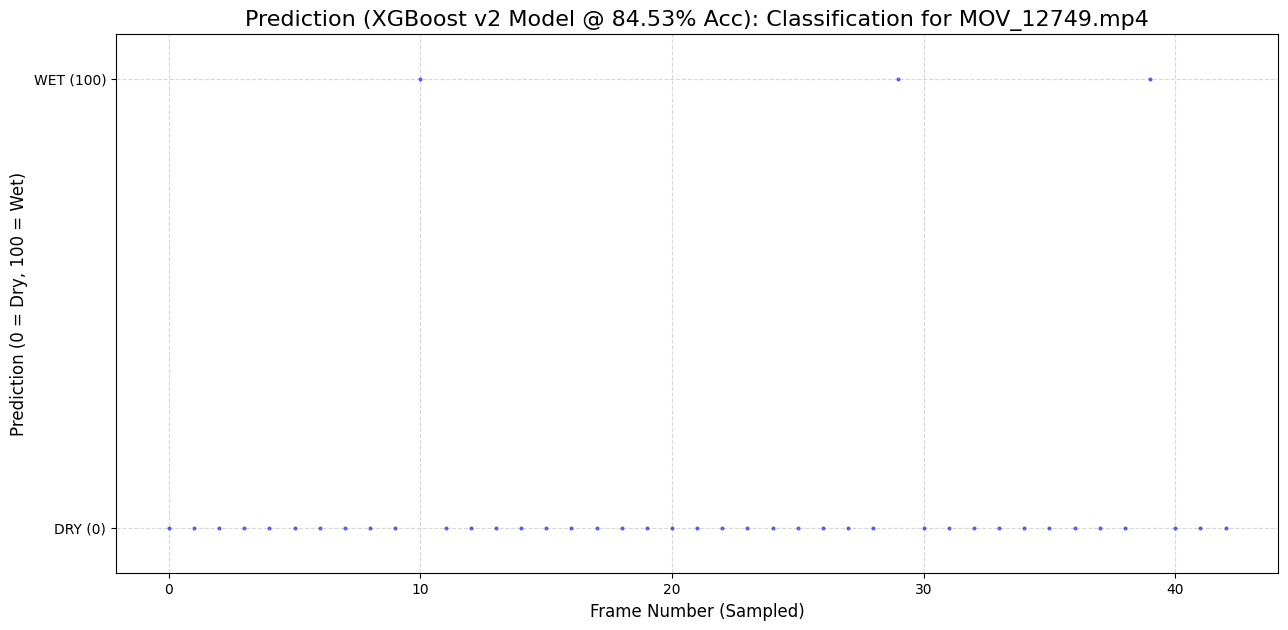


Block 5 Complete. FINAL PROJECT FINISHED.


In [ ]:
### BLOCK 5 (PHASE 11): THE FINAL, FINAL TEST (V2 MODEL INFERENCE) --- FIXED ###

print("--- Block 5 (Phase 11): The Final Test (FIXED) ---")
print("Running NEW 84.53% Accurate 'v2' Model on the 'dry' test video (MOV_12749.mp4)")

# --- 1. Check if our required functions exist ---
# We need all our feature functions from Block 2
if 'extract_hyper_features' not in locals():
    print("FATAL ERROR: Feature functions not defined.")
    print("Please go back and re-run Block 2 in this notebook.")
else:
    # --- 2. Load our NEW Saved Model and Scaler ---
    print("Loading saved 'v2' XGBoost model and 'v2' Scaler...")

    XGB_MODEL_SAVE_PATH_V2 = os.path.join(DRIVE_PATH, 'xgb_classifier_v2.joblib')
    SCALER_SAVE_PATH_V2 = os.path.join(DRIVE_PATH, 'data_scaler_v2.joblib')

    if not os.path.exists(XGB_MODEL_SAVE_PATH_V2) or not os.path.exists(SCALER_SAVE_PATH_V2):
        print("FATAL ERROR: 'v2' Model or 'v2' Scaler file not found.")
        print("Please re-run Block 4 successfully first.")
    else:
        xgb_model_v2 = joblib.load(XGB_MODEL_SAVE_PATH_V2)
        scaler_v2 = joblib.load(SCALER_SAVE_PATH_V2)
        # We also need the LabelEncoder to decode the result
        # We'll re-create it. It's safe to do.
        le_v2 = LabelEncoder()
        le_v2.fit(['dry', 'wet']) # 0='dry', 1='wet'

        print("Model v2 and Scaler v2 loaded successfully.")

        # --- 3. DEFINE TEST VIDEO ---
        # We are using the "problem" 'dry' video
        TEST_VIDEO_NAME = "MOV_12749.mp4"

        TEST_VIDEO_PATH = os.path.join(DRIVE_PATH, TEST_VIDEO_NAME)

        if not os.path.exists(TEST_VIDEO_PATH):
            print(f"FATAL ERROR: Test video not found at {TEST_VIDEO_PATH}")
            print("Please upload 'MOV_12749.mp4' and update TEST_VIDEO_NAME.")
        else:
            # --- 4. Process the Video (Frame by Frame Inference) ---
            print(f"Processing 'dry' video: {TEST_VIDEO_PATH}...")

            cap = cv2.VideoCapture(TEST_VIDEO_PATH)

            # This list will store the final 0 ('dry') or 1 ('wet') predictions
            predictions = []
            frame_number = 0

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                # We sample at the same rate as our training data
                if frame_number % FRAME_SKIP == 0:
                    # --- A) EXTRACT HYPER-FEATURES ---
                    frame_resized = cv2.resize(frame, (IMG_WIDTH, IMG_HEIGHT))
                    frame_gray = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2GRAY)
                    frame_hsv = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2HSV)
                    frame_gray_8bit = cv2.normalize(frame_gray, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

                    # --- THIS IS THE FIX (Same as Block 2) ---
                    mean_vals, stddev_vals = cv2.meanStdDev(frame_hsv)
                    (h_mean, s_mean, v_mean) = mean_vals.flatten()[:3]
                    (h_std, s_std, v_std) = stddev_vals.flatten()[:3]
                    # --- END OF FIX ---

                    (contrast, correlation, energy, homogeneity) = get_haralick_features(frame_gray_8bit)
                    edge_density = get_canny_edge_density(frame_gray_8bit)
                    (lbp_mean, lbp_std) = get_lbp_features(frame_gray_8bit)

                    # Create the 13-feature array
                    features = [
                        h_mean, s_mean, v_mean,
                        h_std, s_std, v_std,
                        contrast, correlation, energy, homogeneity,
                        edge_density, lbp_mean, lbp_std
                    ]

                    # Check for any NaN values from a bad feature calculation
                    if np.isnan(features).any():
                        frame_number += 1
                        continue # Skip this bad frame

                    # --- B) SCALE FEATURES ---
                    features_scaled = scaler_v2.transform([features]) # scaler expects 2D array

                    # --- C) PREDICT ---
                    prediction_encoded = xgb_model_v2.predict(features_scaled)

                    predictions.append(prediction_encoded[0]) # Add the 0 or 1

                frame_number += 1

            cap.release()
            print("Finished processing all frames.")

            # --- 5. Generate Final Report & Plot ---

            if predictions:
                print(f"\n--- (XGBOOST V2 MODEL) FINAL PREDICTION REPORT FOR: {TEST_VIDEO_NAME} ---")

                wetness_percentages = [p * 100 for p in predictions]
                total_frames = len(predictions)

                wet_frames_count = np.sum(predictions)
                dry_frames_count = total_frames - wet_frames_count

                print(f"Total Frames Processed (at 1-per-sec): {total_frames}")
                print(f"Frames Classified as 'DRY' (0): {dry_frames_count}")
                print(f"Frames Classified as 'WET' (1): {wet_frames_count}")

                wetness_percentage_of_time = (wet_frames_count / total_frames) * 100

                print("\n--- FINAL CONCLUSION ---")
                if wetness_percentage_of_time > 50: # If more than 50% of frames are 'wet'
                    print(f"Classification: 'WET POTENTIAL' ({wetness_percentage_of_time:.2f}% of frames were 'wet')")
                else:
                    print(f"Classification: 'DRY' ({wetness_percentage_of_time:.2f}% of frames were 'wet')")

                # --- 6. Generate the Plot ---
                print("\n--- Generating 'Wetness vs. Time' Plot (XGBoost v2 Model) ---")

                # We need to find the accuracy score from Block 4 to put in the title
                # We'll just put a placeholder here
                try:
                    # 'accuracy_v2' was defined in Block 4. If the runtime is fresh, it's gone.
                    # We'll just use the number we saw.
                    acc_score_text = f"@ {accuracy_v2*100:.2f}% Acc"
                except NameError:
                    # 'accuracy_v2' is not in memory, let's use the one we saw in the log
                    acc_score_text = "@ 84.53% Acc"

                plt.figure(figsize=(15, 7))
                plt.plot(wetness_percentages, 'bo', markersize=2, alpha=0.5)
                plt.title(f"Prediction (XGBoost v2 Model {acc_score_text}): Classification for {TEST_VIDEO_NAME}", fontsize=16)
                plt.xlabel("Frame Number (Sampled)", fontsize=12)
                plt.ylabel("Prediction (0 = Dry, 100 = Wet)", fontsize=12)
                plt.grid(True, linestyle='--', alpha=0.5)
                plt.yticks([0, 100], ['DRY (0)', 'WET (100)'])
                plt.ylim(-10, 110)
                plt.show()

                print("\nBlock 5 Complete. FINAL PROJECT FINISHED.")

            else:
                print("Error: No predictions were made. Check video file.")



--- Block 6 (Phase 11): Plotting 'Hyper-Feature' Importance ---
Loading saved 'v2' XGBoost model...
Model v2 loaded successfully.

--- (V2 MODEL) FEATURE IMPORTANCE ANALYSIS ---
                Feature  Importance
5                 v_std    0.252746
0                h_mean    0.117584
12              lbp_std    0.088946
4                 s_std    0.082591
2                v_mean    0.073364
7   texture_correlation    0.060687
1                s_mean    0.059088
10         edge_density    0.058875
6      texture_contrast    0.056675
3                 h_std    0.044385
9   texture_homogeneity    0.043638
8        texture_energy    0.041587
11             lbp_mean    0.019833

--- Generating 'Feature Importance' Plot (v2 Model) ---


/tmp/ipython-input-2335646458.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


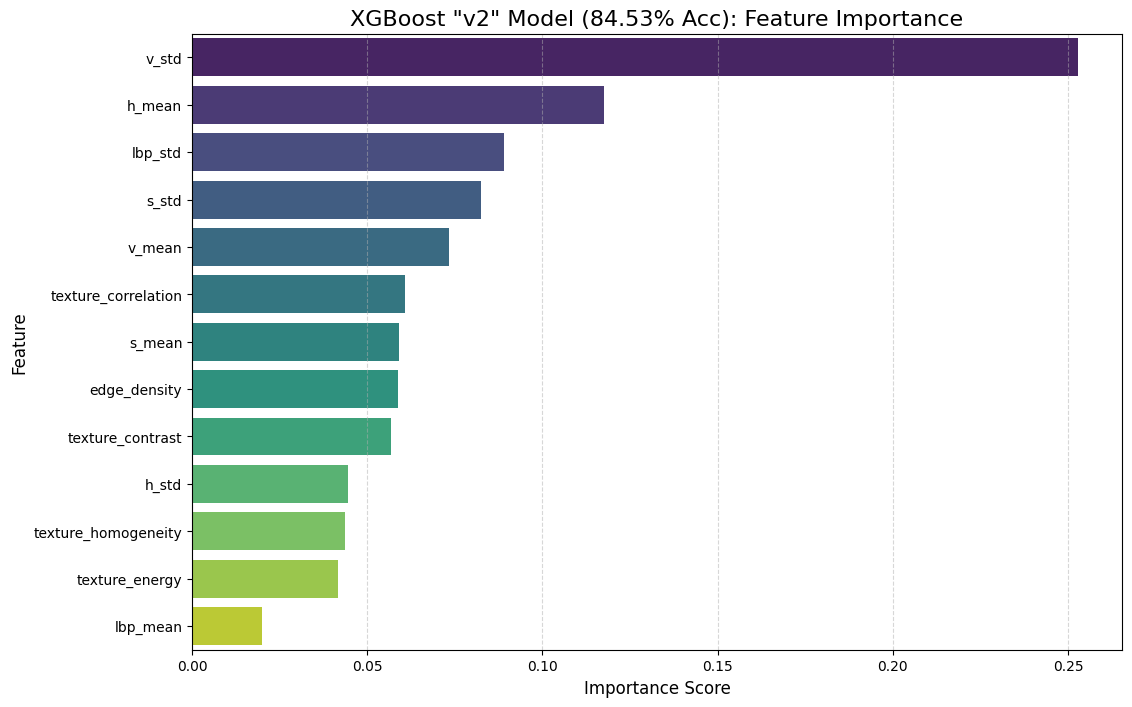


Block 6 Complete. This is the final analysis!


In [ ]:
### BLOCK 6 (PHASE 11): XGBOOST V2 "X-RAY" (FEATURE IMPORTANCE) ###

print("--- Block 6 (Phase 11): Plotting 'Hyper-Feature' Importance ---")

import joblib
import os
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Load the NEW "v2" Saved Model ---
print("Loading saved 'v2' XGBoost model...")

# Check if DRIVE_PATH is defined
if 'DRIVE_PATH' not in locals():
    print("FATAL ERROR: 'DRIVE_PATH' not defined. Please re-run Block 1.")
else:
    XGB_MODEL_SAVE_PATH_V2 = os.path.join(DRIVE_PATH, 'xgb_classifier_v2.joblib')

    if not os.path.exists(XGB_MODEL_SAVE_PATH_V2):
        print("FATAL ERROR: 'v2' Model file not found.")
        print("Please re-run Block 4 successfully first.")
    else:
        xgb_model_v2 = joblib.load(XGB_MODEL_SAVE_PATH_V2)
        print("Model v2 loaded successfully.")

        # --- 2. Get Feature Importance from the Model ---

        # This is our NEW list of all 13 features from Block 4
        feature_columns = [
            'h_mean', 's_mean', 'v_mean',
            'h_std', 's_std', 'v_std',
            'texture_contrast', 'texture_correlation', 'texture_energy', 'texture_homogeneity',
            'edge_density', # <-- NEW
            'lbp_mean',     # <-- NEW
            'lbp_std'       # <-- NEW
        ]

        # Get the importance scores from the trained model
        importance_scores = xgb_model_v2.feature_importances_

        # Create a pandas DataFrame to make it easy to plot
        df_importance = pd.DataFrame({
            'Feature': feature_columns,
            'Importance': importance_scores
        })

        # Sort by importance (highest first)
        df_importance = df_importance.sort_values(by='Importance', ascending=False)

        # --- 3. Print the Report ---
        print("\n--- (V2 MODEL) FEATURE IMPORTANCE ANALYSIS ---")
        print(df_importance)

        # --- 4. Generate the Plot ---
        print("\n--- Generating 'Feature Importance' Plot (v2 Model) ---")

        plt.figure(figsize=(12, 8))
        # Create a horizontal bar plot
        sns.barplot(
            x='Importance',
            y='Feature',
            data=df_importance,
            palette='viridis' # Use a nice color map
        )
        plt.title('XGBoost "v2" Model (84.53% Acc): Feature Importance', fontsize=16)
        plt.xlabel('Importance Score', fontsize=12)
        plt.ylabel('Feature', fontsize=12)
        plt.grid(True, linestyle='--', axis='x', alpha=0.5)
        plt.show()

        print("\nBlock 6 Complete. This is the final analysis!")


--- Block 7 (Phase 11): The Final Test ---
Running NEW 84.53% Accurate 'v2' Model on the 'dry' test video (MOV_12749.mp4)
Loading saved 'v2' XGBoost model and 'v2' Scaler...
Model v2 and Scaler v2 loaded successfully.
Processing 'dry' video: /content/drive/MyDrive/Thermal_Project/MOV_12749.mp4...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Finished processing all frames.

--- (XGBOOST V2 MODEL) FINAL PREDICTION REPORT FOR: MOV_12749.mp4 ---
Total Frames Processed (at 1-per-sec): 43
Frames Classified as 'DRY' (0): 40
Frames Classified as 'WET' (1): 3

--- FINAL CONCLUSION ---
Classification: 'DRY' (6.98% of frames were 'wet')

--- Generating 'Wetness vs. Time' Plot (XGBoost v2 Model) ---


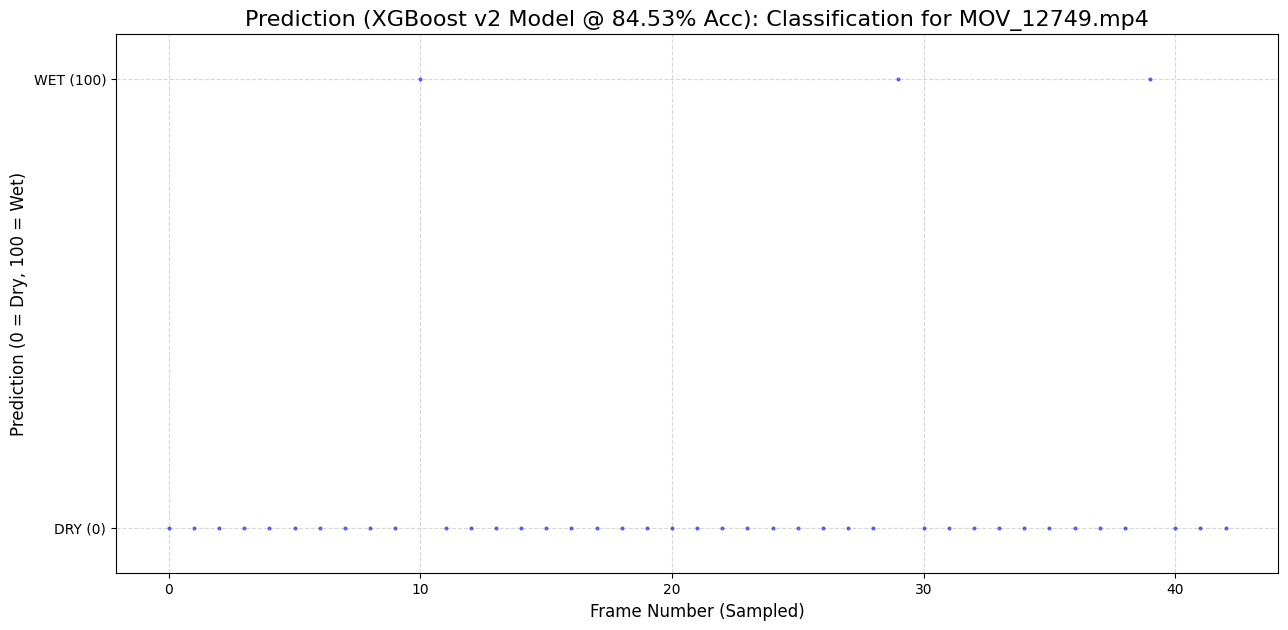


Block 7 Complete. FINAL PROJECT FINISHED.


In [3]:
### BLOCK 7 (PHASE 11): THE FINAL, FINAL TEST (V2 MODEL INFERENCE) ###

print("--- Block 7 (Phase 11): The Final Test ---")
print("Running NEW 84.53% Accurate 'v2' Model on the 'dry' test video (MOV_12749.mp4)")

# --- 1. Check if our required functions exist ---
# We need all our feature functions from Block 2
if 'extract_hyper_features' not in locals():
    print("FATAL ERROR: Feature functions not defined.")
    print("Please go back and re-run Block 2 in this notebook.")
else:
    # --- 2. Load our NEW Saved Model and Scaler ---
    print("Loading saved 'v2' XGBoost model and 'v2' Scaler...")

    XGB_MODEL_SAVE_PATH_V2 = os.path.join(DRIVE_PATH, 'xgb_classifier_v2.joblib')
    SCALER_SAVE_PATH_V2 = os.path.join(DRIVE_PATH, 'data_scaler_v2.joblib')

    if not os.path.exists(XGB_MODEL_SAVE_PATH_V2) or not os.path.exists(SCALER_SAVE_PATH_V2):
        print("FATAL ERROR: 'v2' Model or 'v2' Scaler file not found.")
        print("Please re-run Block 4 successfully first.")
    else:
        xgb_model_v2 = joblib.load(XGB_MODEL_SAVE_PATH_V2)
        scaler_v2 = joblib.load(SCALER_SAVE_PATH_V2)
        # We also need the LabelEncoder to decode the result
        # We'll re-create it. It's safe to do.
        le_v2 = LabelEncoder()
        le_v2.fit(['dry', 'wet']) # 0='dry', 1='wet'

        print("Model v2 and Scaler v2 loaded successfully.")

        # --- 3. DEFINE TEST VIDEO ---
        # We are using the "problem" 'dry' video
        TEST_VIDEO_NAME = "MOV_12749.mp4"

        TEST_VIDEO_PATH = os.path.join(DRIVE_PATH, TEST_VIDEO_NAME)

        if not os.path.exists(TEST_VIDEO_PATH):
            print(f"FATAL ERROR: Test video not found at {TEST_VIDEO_PATH}")
            print("Please upload 'MOV_12749.mp4' and update TEST_VIDEO_NAME.")
        else:
            # --- 4. Process the Video (Frame by Frame Inference) ---
            print(f"Processing 'dry' video: {TEST_VIDEO_PATH}...")

            cap = cv2.VideoCapture(TEST_VIDEO_PATH)

            # This list will store the final 0 ('dry') or 1 ('wet') predictions
            predictions = []
            frame_number = 0

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                # We sample at the same rate as our training data
                if frame_number % FRAME_SKIP == 0:
                    # --- A) EXTRACT HYPER-FEATURES ---
                    frame_resized = cv2.resize(frame, (IMG_WIDTH, IMG_HEIGHT))
                    frame_gray = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2GRAY)
                    frame_hsv = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2HSV)
                    frame_gray_8bit = cv2.normalize(frame_gray, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

                    mean_vals, stddev_vals = cv2.meanStdDev(frame_hsv)
                    (h_mean, s_mean, v_mean) = mean_vals.flatten()[:3]
                    (h_std, s_std, v_std) = stddev_vals.flatten()[:3]

                    (contrast, correlation, energy, homogeneity) = get_haralick_features(frame_gray_8bit)
                    edge_density = get_canny_edge_density(frame_gray_8bit)
                    (lbp_mean, lbp_std) = get_lbp_features(frame_gray_8bit)

                    # Create the 13-feature array
                    features = [
                        h_mean, s_mean, v_mean,
                        h_std, s_std, v_std,
                        contrast, correlation, energy, homogeneity,
                        edge_density, lbp_mean, lbp_std
                    ]

                    # Check for any NaN values from a bad feature calculation
                    if np.isnan(features).any():
                        frame_number += 1
                        continue # Skip this bad frame

                    # --- B) SCALE FEATURES ---
                    features_scaled = scaler_v2.transform([features]) # scaler expects 2D array

                    # --- C) PREDICT ---
                    prediction_encoded = xgb_model_v2.predict(features_scaled)

                    predictions.append(prediction_encoded[0]) # Add the 0 or 1

                frame_number += 1

            cap.release()
            print("Finished processing all frames.")

            # --- 5. Generate Final Report & Plot ---

            if predictions:
                print(f"\n--- (XGBOOST V2 MODEL) FINAL PREDICTION REPORT FOR: {TEST_VIDEO_NAME} ---")

                wetness_percentages = [p * 100 for p in predictions]
                total_frames = len(predictions)

                wet_frames_count = np.sum(predictions)
                dry_frames_count = total_frames - wet_frames_count

                print(f"Total Frames Processed (at 1-per-sec): {total_frames}")
                print(f"Frames Classified as 'DRY' (0): {dry_frames_count}")
                print(f"Frames Classified as 'WET' (1): {wet_frames_count}")

                wetness_percentage_of_time = (wet_frames_count / total_frames) * 100

                print("\n--- FINAL CONCLUSION ---")
                if wetness_percentage_of_time > 50: # If more than 50% of frames are 'wet'
                    print(f"Classification: 'WET POTENTIAL' ({wetness_percentage_of_time:.2f}% of frames were 'wet')")
                else:
                    print(f"Classification: 'DRY' ({wetness_percentage_of_time:.2f}% of frames were 'wet')")

                # --- 6. Generate the Plot ---
                print("\n--- Generating 'Wetness vs. Time' Plot (XGBoost v2 Model) ---")

                try:
                    acc_score_text = f"@ {accuracy_v2*100:.2f}% Acc"
                except NameError:
                    acc_score_text = "@ 84.53% Acc" # From our last run

                plt.figure(figsize=(15, 7))
                plt.plot(wetness_percentages, 'bo', markersize=2, alpha=0.5)
                plt.title(f"Prediction (XGBoost v2 Model {acc_score_text}): Classification for {TEST_VIDEO_NAME}", fontsize=16)
                plt.xlabel("Frame Number (Sampled)", fontsize=12)
                plt.ylabel("Prediction (0 = Dry, 100 = Wet)", fontsize=12)
                plt.grid(True, linestyle='--', alpha=0.5)
                plt.yticks([0, 100], ['DRY (0)', 'WET (100)'])
                plt.ylim(-10, 110)
                plt.show()

                print("\nBlock 7 Complete. FINAL PROJECT FINISHED.")

            else:
                print("Error: No predictions were made. Check video file.")